<a href="https://colab.research.google.com/github/SaraBSalazar/courses/blob/main/C%C3%B3pia_de_BIOMICS_UniProt_API_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises

In [2]:
import sys
import json
import requests
from prettytable import PrettyTable

# Documentation: https://www.uniprot.org/help/api
WEBSITE_API = "https://rest.uniprot.org/"

# Documentation: https://www.ebi.ac.uk/proteins/api/doc/
PROTEINS_API = "https://www.ebi.ac.uk/proteins/api"

# Helper function to download data
def get_url(url, **kwargs):
  response = requests.get(url, **kwargs);

  if not response.ok:
    print(response.text)
    response.raise_for_status()
    sys.exit()

  return response

In [ ]:
# Template of an API search:
r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=")
data = r.json()
n_results = len(data["results"])
print(f"Number of results: {n_results}\n")

Number of results: 0



In [ ]:
# Exercise 1: Getting a set of UniProtKB accessions
# Let's search for accessions of the HPSE gene in Mammalia. Get only Swiss-Prot (reviewed accessions)
# PS: Example of a search: "{WEBSITE_API}/uniprotkb/search?query=(ec:3.2.1.23) AND (xref:pfam-PF21317)"
# Finally, print the variable "data" (result "r" in JSON format)

# You can start by searching in our website the query to get used to. You can also look into the query list: https://www.uniprot.org/help/query-fields
r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=(gene:HPSE) AND (taxonomy_id:40674) AND (reviewed:true)")
data = r.json()
n_results = len(data["results"])
print(f"Number of results: {n_results}\n")
print(data)


Number of results: 4

{'results': [{'entryType': 'UniProtKB reviewed (Swiss-Prot)', 'primaryAccession': 'Q71RP1', 'secondaryAccessions': ['Q9QZF8'], 'uniProtkbId': 'HPSE_RAT', 'entryAudit': {'firstPublicDate': '2005-10-11', 'lastAnnotationUpdateDate': '2026-09-02', 'lastSequenceUpdateDate': '2004-07-05', 'entryVersion': 115, 'sequenceVersion': 1}, 'annotationScore': 5.0, 'organism': {'scientificName': 'Rattus norvegicus', 'commonName': 'Rat', 'taxonId': 10116, 'lineage': ['Eukaryota', 'Metazoa', 'Chordata', 'Craniata', 'Vertebrata', 'Euteleostomi', 'Mammalia', 'Eutheria', 'Euarchontoglires', 'Glires', 'Rodentia', 'Myomorpha', 'Muroidea', 'Muridae', 'Murinae', 'Rattus']}, 'proteinExistence': '2: Evidence at transcript level', 'proteinDescription': {'recommendedName': {'fullName': {'value': 'Heparanase'}, 'ecNumbers': [{'value': '3.2.1.166'}]}, 'alternativeNames': [{'fullName': {'value': 'Endo-glucoronidase'}}], 'contains': [{'recommendedName': {'fullName': {'value': 'Heparanase 8 kDa su

In [3]:
# Exercise 2: Transforming the output data into readible information
# Get the last result in the TSV format. Print as text ("r.text")

# For all supported formats see: https://www.uniprot.org/help/api_queries#list-of-all-formats

r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=(gene:HPSE) AND (taxonomy_id:40674) AND reviewed:true&format=tsv")

print(r.text)



Entry	Entry Name	Reviewed	Protein names	Gene Names	Organism	Length
Q71RP1	HPSE_RAT	reviewed	Heparanase (EC 3.2.1.166) (Endo-glucoronidase) [Cleaved into: Heparanase 8 kDa subunit; Heparanase 50 kDa subunit]	Hpse Hep	Rattus norvegicus (Rat)	536
Q6YGZ1	HPSE_MOUSE	reviewed	Heparanase (EC 3.2.1.166) (Endo-glucoronidase) [Cleaved into: Heparanase 8 kDa subunit; Heparanase 50 kDa subunit]	Hpse Hpa	Mus musculus (Mouse)	535
Q9Y251	HPSE_HUMAN	reviewed	Heparanase (EC 3.2.1.166) (Endo-glucoronidase) (Heparanase-1) (Hpa1) [Cleaved into: Heparanase 8 kDa subunit; Heparanase 50 kDa subunit]	HPSE HEP HPA HPA1 HPR1 HPSE1 HSE1	Homo sapiens (Human)	543
Q9MYY0	HPSE_BOVIN	reviewed	Heparanase (EC 3.2.1.166) [Cleaved into: Heparanase 8 kDa subunit; Heparanase 50 kDa subunit]	HPSE	Bos taurus (Bovine)	545



In [ ]:
# Exercise 3: Perform a complex search
# Finally let's do a more complex search by getting only the fields: Entry Name,Entry, Length and Catalytic activity. Print it in the same way

# For all fields you can find a list here: https://www.uniprot.org/help/return_fields

r = get_url(f"{WEBSITE_API}/uniprotkb/search?query=(gene:HPSE) AND (taxonomy_id:40674) AND reviewed:true&format=tsv&field=accession,id,length,cc_catalytic_activity")

print(r.text)


Entry	Entry Name	Reviewed	Protein names	Gene Names	Organism	Length
Q71RP1	HPSE_RAT	reviewed	Heparanase (EC 3.2.1.166) (Endo-glucoronidase) [Cleaved into: Heparanase 8 kDa subunit; Heparanase 50 kDa subunit]	Hpse Hep	Rattus norvegicus (Rat)	536
Q6YGZ1	HPSE_MOUSE	reviewed	Heparanase (EC 3.2.1.166) (Endo-glucoronidase) [Cleaved into: Heparanase 8 kDa subunit; Heparanase 50 kDa subunit]	Hpse Hpa	Mus musculus (Mouse)	535
Q9Y251	HPSE_HUMAN	reviewed	Heparanase (EC 3.2.1.166) (Endo-glucoronidase) (Heparanase-1) (Hpa1) [Cleaved into: Heparanase 8 kDa subunit; Heparanase 50 kDa subunit]	HPSE HEP HPA HPA1 HPR1 HPSE1 HSE1	Homo sapiens (Human)	543
Q9MYY0	HPSE_BOVIN	reviewed	Heparanase (EC 3.2.1.166) [Cleaved into: Heparanase 8 kDa subunit; Heparanase 50 kDa subunit]	HPSE	Bos taurus (Bovine)	545



In [ ]:
# Exercise 4: Search a single UniProtKB accession
# Search only O60260. More specifically only it's catalytic activity information
# PS: print the results now using: print(json.dumps(r.json(), indent=2))

r = get_url(f"{WEBSITE_API}/uniprotkb/O60260")

print(json.dumps(r.json(), indent=2))

{
  "entryType": "UniProtKB reviewed (Swiss-Prot)",
  "primaryAccession": "O60260",
  "secondaryAccessions": [
    "A3FG77",
    "A8K975",
    "D3JZW7",
    "D3K2X0",
    "Q5TFV8",
    "Q5VVX4",
    "Q6Q2I6",
    "Q8NI41",
    "Q8NI43",
    "Q8NI44",
    "Q8WW07"
  ],
  "uniProtkbId": "PRKN_HUMAN",
  "entryAudit": {
    "firstPublicDate": "2004-10-11",
    "lastAnnotationUpdateDate": "2026-09-02",
    "lastSequenceUpdateDate": "2006-10-17",
    "entryVersion": 238,
    "sequenceVersion": 2
  },
  "annotationScore": 5.0,
  "organism": {
    "scientificName": "Homo sapiens",
    "commonName": "Human",
    "taxonId": 9606,
    "lineage": [
      "Eukaryota",
      "Metazoa",
      "Chordata",
      "Craniata",
      "Vertebrata",
      "Euteleostomi",
      "Mammalia",
      "Eutheria",
      "Euarchontoglires",
      "Primates",
      "Haplorrhini",
      "Catarrhini",
      "Hominidae",
      "Homo"
    ]
  },
  "proteinExistence": "1: Evidence at protein level",
  "proteinDescription":

In [ ]:
# Exercise 5: Now search the Natural variants for the same UniProtKB accession
# PS: print len(r.json()['features']) to see how many variants
# PS: print json.dumps(r.json()['features'][0], indent=2) to see the 1st variant information


print(len(r.json()['features']))
print(json.dumps(r.json()['features'][0], indent=2))

165
{
  "type": "Chain",
  "location": {
    "start": {
      "value": 1,
      "modifier": "EXACT"
    },
    "end": {
      "value": 465,
      "modifier": "EXACT"
    }
  },
  "description": "E3 ubiquitin-protein ligase parkin",
  "featureId": "PRO_0000058576"
}


In [ ]:
# Exercise 6: Use the Protein API instead.
# Now try running:
r_proteins_api = get_url(f"{PROTEINS_API}/variation/O60260")
print(f"number of variants in Proteins API: {len(r_proteins_api.json()['features'])}")
print(json.dumps(r_proteins_api.json()['features'][1], indent=2))



number of variants in Proteins API: 935
{
  "type": "VARIANT",
  "alternativeSequence": "T",
  "begin": "1",
  "end": "1",
  "xrefs": [
    {
      "name": "ClinGen",
      "id": "CA4090563",
      "url": "https://reg.clinicalgenome.org/redmine/projects/registry/genboree_registry/by_caid?caid=CA4090563"
    },
    {
      "name": "ClinVar",
      "id": "RCV000992706",
      "url": "https://www.ncbi.nlm.nih.gov/clinvar/RCV000992706",
      "alternativeUrl": "https://www.ensembl.org/homo_sapiens/Variation/Explore?v=RCV000992706"
    },
    {
      "name": "ClinVar",
      "id": "RCV001784521",
      "url": "https://www.ncbi.nlm.nih.gov/clinvar/RCV001784521",
      "alternativeUrl": "https://www.ensembl.org/homo_sapiens/Variation/Explore?v=RCV001784521"
    },
    {
      "name": "ClinVar",
      "id": "RCV005629857",
      "url": "https://www.ncbi.nlm.nih.gov/clinvar/RCV005629857",
      "alternativeUrl": "https://www.ensembl.org/homo_sapiens/Variation/Explore?v=RCV005629857"
    },
    

# Useful information: How to run Multiple Alignment

In [ ]:
# Manually selected accessions
accessions = ",".join(["O60260", "Q7KTX7", "Q9WVS6", "Q9JK66"])

r = get_url(f"{WEBSITE_API}/uniprotkb/accessions?accessions={accessions}&format=fasta")
fasta = r.text
print(fasta)

>sp|O60260|PRKN_HUMAN E3 ubiquitin-protein ligase parkin OS=Homo sapiens OX=9606 GN=PRKN PE=1 SV=2
MIVFVRFNSSHGFPVEVDSDTSIFQLKEVVAKRQGVPADQLRVIFAGKELRNDWTVQNCD
LDQQSIVHIVQRPWRKGQEMNATGGDDPRNAAGGCEREPQSLTRVDLSSSVLPGDSVGLA
VILHTDSRKDSPPAGSPAGRSIYNSFYVYCKGPCQRVQPGKLRVQCSTCRQATLTLTQGP
SCWDDVLIPNRMSGECQSPHCPGTSAEFFFKCGAHPTSDKETSVALHLIATNSRNITCIT
CTDVRSPVLVFQCNSRHVICLDCFHLYCVTRLNDRQFVHDPQLGYSLPCVAGCPNSLIKE
LHHFRILGEEQYNRYQQYGAEECVLQMGGVLCPRPGCGAGLLPEPDQRKVTCEGGNGLGC
GFAFCRECKEAYHEGECSAVFEASGTTTQAYRVDERAAEQARWEAASKETIKKTTKPCPR
CHVPVEKNGGCMHMKCPQPQCRLEWCWNCGCEWNRVCMGDHWFDV
>sp|Q7KTX7|PRKN_DROME E3 ubiquitin-protein ligase parkin OS=Drosophila melanogaster OX=7227 GN=park PE=1 SV=1
MSFIFKFIATFVRKMLELLQFGGKTLTHTLSIYVKTNTGKTLTVNLEPQWDIKNVKELVA
PQLGLQPDDLKIIFAGKELSDATTIEQCDLGQQSVLHAIRLRPPVQRQKIQSATLEEEEP
SLSDEASKPLNETLLDLQLESEERLNITDEERVRAKAHFFVHCSQCDKLCNGKLRVRCAL
CKGGAFTVHRDPECWDDVLKSRRIPGHCESLEVACVDNAAGDPPFAEFFFKCAEHVSGGE
KDFAAPLNLIKNNIKNVPCLACTDVSDTVLVFPCASQHVTCIDCFRHYCRSRLGERQFMP
HPDFGYTLPCPAG

In [ ]:
# submit align job using clustalo
r = requests.post("https://www.ebi.ac.uk/Tools/services/rest/clustalo/run", data={
    "email": "example@example.com",
    "iterations": 0,
    "outfmt": "clustal_num",
    "order": "aligned",
    "sequence": fasta
})

# documentation here https://www.ebi.ac.uk/seqdb/confluence/display/JDSAT/Clustal+Omega+Help+and+Documentation#ClustalOmegaHelpandDocumentation-RESTAPI

job_id = r.text
print(job_id)

# get job status
r = get_url(f"https://www.ebi.ac.uk/Tools/services/rest/clustalo/status/{job_id}")
print(r.text)

clustalo-R20261009-114231-0782-46338554-p2m
QUEUED


In [ ]:
# Run the following again to check the status until finished
r = get_url(f"https://www.ebi.ac.uk/Tools/services/rest/clustalo/status/{job_id}")
print(r.text)

NOT_FOUND


In [ ]:
r = get_url(f"https://www.ebi.ac.uk/Tools/services/rest/clustalo/result/{job_id}/aln-clustal_num")
print(r.text)

# * : Fully conserved residues.
# : : Conservation between groups of strongly similar properties (Gonnet PAM 250 score > 0.5).
# . : Conservation between groups of weakly similar properties (Gonnet PAM 250 score ≤ 0.5).
#   : Non-conserved residues.

CLUSTAL O(1.2.4) multiple sequence alignment


sp|Q7KTX7|PRKN_DROME      MSFIFKFIATFVRKMLELLQFGGKTLTHTLSIYVKTNTGKTLTVNLEPQWDIKNVKELVA	60
sp|O60260|PRKN_HUMAN      -----------------------------MIVFVRFNSSHGFPVEVDSDTSIFQLKEVVA	31
sp|Q9WVS6|PRKN_MOUSE      -----------------------------MIVFVRFNSSYGFPVEVDSDTSILQLKEVVA	31
sp|Q9JK66|PRKN_RAT        -----------------------------MIVFVRFNSSYGFPVEVDSDTSIFQLKEVVA	31
                                                       : ::*: *:.  : *::: : .* ::**:**

sp|Q7KTX7|PRKN_DROME      PQLGLQPDDLKIIFAGKELSDATTIEQCDLGQQSVLHAIRLRPPVQRQKIQSATLEEEEP	120
sp|O60260|PRKN_HUMAN      KRQGVPADQLRVIFAGKELRNDWTVQNCDLDQQSIVHIVQRP-WRKGQEMNAT--GGDDP	88
sp|Q9WVS6|PRKN_MOUSE      KRQGVPADQLRVIFAGKELPNHLTVQNCDLEQQSIVHIVQRP-RRRSHETNAS--GGDEP	88
sp|Q9JK66|PRKN_RAT        KRQGVPADQLRVIFAGKELQNHLTVQNCDLEQQSIVHIVQRP-QRKSHETNAS--GGDKP	88
                           : *:  *:*::******* :  *:::*** ***::* ::     : :: :::    :.*

sp|Q7KTX7|PRKN_DROME      SLSDEA--SKPL--------------NETL

# Useful information: How to process ID Mapping

In [ ]:
# Manually selected accessions
accessions = ["O60260", "Q7KTX7", "Q9WVS6", "Q9JK66"]

# Send job to ID mapping endpoint
r = requests.post(f"{WEBSITE_API}/idmapping/run", data={
    "from": "UniProtKB_AC-ID",
    "to": "RefSeq_Nucleotide",
    "ids": accessions
})
job_id = r.json()['jobId']
print("job ID:", job_id)

r = get_url(f"{WEBSITE_API}/idmapping/status/{job_id}")
print(json.dumps(r.json(), indent=2))

# Run the following again to check the status until finished

job ID: n675epOVmd
{
  "results": [
    {
      "from": "O60260",
      "to": "NM_004562.3"
    },
    {
      "from": "O60260",
      "to": "NM_013987.3"
    },
    {
      "from": "O60260",
      "to": "NM_013988.3"
    },
    {
      "from": "Q7KTX7",
      "to": "NM_168884.2"
    },
    {
      "from": "Q7KTX7",
      "to": "NM_168885.3"
    },
    {
      "from": "Q9WVS6",
      "to": "NM_001317726.1"
    },
    {
      "from": "Q9WVS6",
      "to": "NM_016694.5"
    },
    {
      "from": "Q9WVS6",
      "to": "XM_030249894.2"
    },
    {
      "from": "Q9JK66",
      "to": "NM_020093.1"
    },
    {
      "from": "Q9JK66",
      "to": "XM_063272057.1"
    }
  ]
}


# *Extra:* Visualisation example

*Note: These examples don't have a biological meaning, they are just there as an example in order to throw data on the screen! Please adjust accordingly to your interests*

In [ ]:
r = get_url(f"{WEBSITE_API}/uniprotkb/stream?query=(gene:MTM1)&fields=mass,reviewed,length,cc_catalytic_activity,annotation_score")
data = r.json()

print(len(data["results"]), data["results"][0])

1146 {'entryType': 'UniProtKB unreviewed (TrEMBL)', 'primaryAccession': 'A0A1S3FYI4', 'annotationScore': 5.0, 'comments': [{'commentType': 'CATALYTIC ACTIVITY', 'reaction': {'name': '1,2-dihexadecanoyl-sn-glycero-3-phospho-(1D-myo-inositol-3,5-bisphosphate) + H2O = 1,2-dihexadecanoyl-sn-glycero-3-phospho-(1D-myo-inositol-5-phosphate) + phosphate', 'reactionCrossReferences': [{'database': 'Rhea', 'id': 'RHEA:45636'}, {'database': 'ChEBI', 'id': 'CHEBI:15377'}, {'database': 'ChEBI', 'id': 'CHEBI:43474'}, {'database': 'ChEBI', 'id': 'CHEBI:78994'}, {'database': 'ChEBI', 'id': 'CHEBI:84968'}], 'evidences': [{'evidenceCode': 'ECO:0000256', 'source': 'ARBA', 'id': 'ARBA00093965'}]}}, {'commentType': 'CATALYTIC ACTIVITY', 'reaction': {'name': '1,2-dioctanoyl-sn-glycero-3-phospho-(1-D-myo-inositol-3-phosphate) + H2O = 1,2-dioctanoyl-sn-glycero-3-phospho-(1D-myo-inositol) + phosphate', 'reactionCrossReferences': [{'database': 'Rhea', 'id': 'RHEA:42328'}, {'database': 'ChEBI', 'id': 'CHEBI:15377

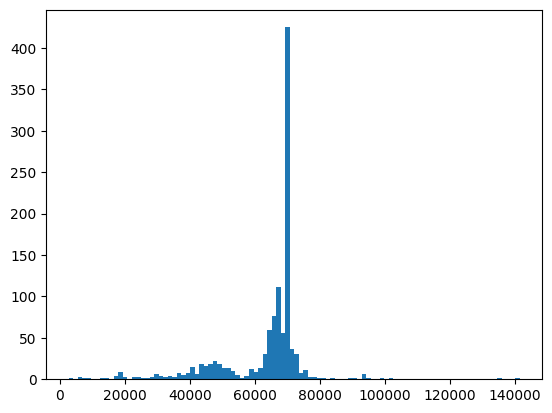

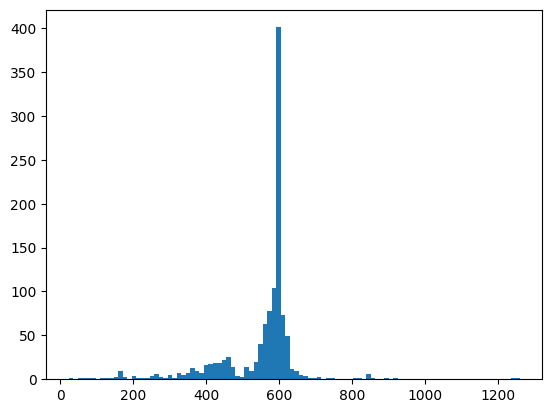

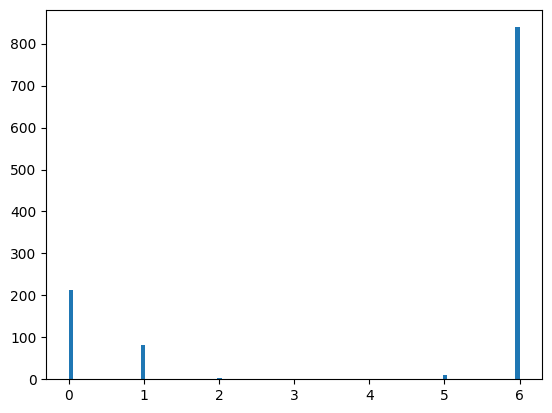

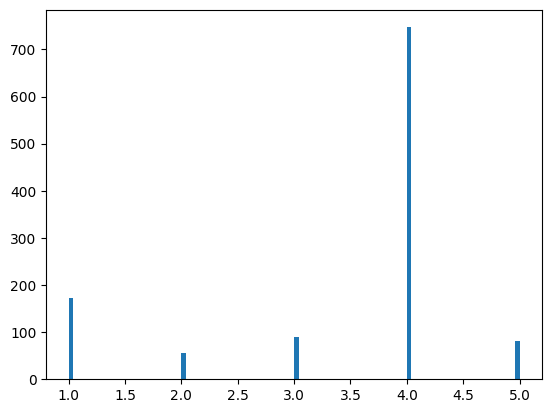

In [ ]:
import matplotlib.pyplot as plt

reviewed = ["grey" if "unreviewed" in entry["entryType"] else "gold" for entry in data["results"]]

mass = [entry["sequence"]["molWeight"] for entry in data["results"]]
plt.hist(mass, bins=100)
plt.show()

length = [entry["sequence"]["length"] for entry in data["results"]]
plt.hist(length, bins=100)
plt.show()

n_cat = [len(entry.get("comments", [])) for entry in data["results"]]
plt.hist(n_cat, bins=100)
plt.show()

score = [entry["annotationScore"] for entry in data["results"]]
plt.hist(score, bins=100)
plt.show()